<a href="https://colab.research.google.com/github/PoojaKumariR-student/Supply-Chain-Demand-Forecasting/blob/main/Supply_Chain_Demand_Forecasting_Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1 - Loading the libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 2 - Loading Dataset**

In [ ]:
df = pd.read_csv("/content/demand_forecasting_dataset.csv")
df

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,region_Europe,region_North America,store_type_Retail,store_type_Wholesale,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand
0,01-01-2023,151,99,0,0,0.983893,1.314333,0,126.932923,0.000000,12566.359330,False,False,True,False,False,True,False,False,95
1,02-01-2023,192,95,1,0,0.977615,1.439582,0,151.355405,0.000000,14378.763510,False,True,False,False,True,False,False,False,101
2,03-01-2023,114,101,0,0,0.983913,1.094795,0,191.701693,0.000000,19361.870950,False,False,False,True,True,False,False,False,33
3,04-01-2023,171,33,0,0,1.191956,0.907672,0,173.106487,0.000000,5712.514059,False,False,False,True,False,True,False,False,82
4,05-01-2023,160,82,0,1,0.855711,1.479690,0,138.587491,10.995213,10114.659150,True,False,False,False,False,False,True,False,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,03-09-2036,135,145,0,0,1.056679,1.070775,0,71.619056,0.000000,10384.763050,False,True,False,True,False,False,True,False,30
4995,04-09-2036,148,30,1,0,0.943824,0.588744,0,156.059583,0.000000,4681.787499,False,True,False,False,False,True,False,False,65
4996,05-09-2036,157,65,0,0,1.126866,0.744654,1,122.872619,0.000000,7986.720266,False,True,False,True,True,False,False,False,55
4997,06-09-2036,138,55,0,0,0.835702,1.409860,0,59.899614,0.000000,3294.478765,False,True,False,True,False,False,True,False,52


# **Step 3 - Undersatanding the Dataset**

In [ ]:
df.head()

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,region_Europe,region_North America,store_type_Retail,store_type_Wholesale,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand
0,01-01-2023,151,99,0,0,0.983893,1.314333,0,126.932923,0.000000,12566.359330,False,False,True,False,False,True,False,False,95
1,02-01-2023,192,95,1,0,0.977615,1.439582,0,151.355405,0.000000,14378.763510,False,True,False,False,True,False,False,False,101
2,03-01-2023,114,101,0,0,0.983913,1.094795,0,191.701693,0.000000,19361.870950,False,False,False,True,True,False,False,False,33
3,04-01-2023,171,33,0,0,1.191956,0.907672,0,173.106487,0.000000,5712.514059,False,False,False,True,False,True,False,False,82
4,05-01-2023,160,82,0,1,0.855711,1.479690,0,138.587491,10.995213,10114.659150,True,False,False,False,False,False,True,False,13


In [ ]:
df.tail()

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,region_Europe,region_North America,store_type_Retail,store_type_Wholesale,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand
4994,03-09-2036,135,145,0,0,1.056679,1.070775,0,71.619056,0.0,10384.763050,False,True,False,True,False,False,True,False,30
4995,04-09-2036,148,30,1,0,0.943824,0.588744,0,156.059583,0.0,4681.787499,False,True,False,False,False,True,False,False,65
4996,05-09-2036,157,65,0,0,1.126866,0.744654,1,122.872619,0.0,7986.720266,False,True,False,True,True,False,False,False,55
4997,06-09-2036,138,55,0,0,0.835702,1.409860,0,59.899614,0.0,3294.478765,False,True,False,True,False,False,True,False,52
4998,07-09-2036,179,52,1,0,0.916238,0.962080,0,136.678104,0.0,7107.261428,True,False,False,True,False,False,False,False,129


In [ ]:
df.shape

(4999, 20)

In [ ]:
df.info

<bound method DataFrame.info of             date  product_id  sales_units  holiday_season  promotion_applied  \
0     01-01-2023         151           99               0                  0   
1     02-01-2023         192           95               1                  0   
2     03-01-2023         114          101               0                  0   
3     04-01-2023         171           33               0                  0   
4     05-01-2023         160           82               0                  1   
...          ...         ...          ...             ...                ...   
4994  03-09-2036         135          145               0                  0   
4995  04-09-2036         148           30               1                  0   
4996  05-09-2036         157           65               0                  0   
4997  06-09-2036         138           55               0                  0   
4998  07-09-2036         179           52               1                  0   

      competitor_price_index  economic_index  weather_impact       price  \
0                   0.983893        1.314333               0  126.932923   
1                   0.977615        1.439582               0  151.355405   
2                   0.983913        1.094795               0  191.701693   
3                   1.191956        0.907672               0  173.106487   
4                   0.855711        1.479690               0  138.587491   
...                      ...             ...             ...         ...   
4994                1.056679        1.070775               0   71.619056   
4995                0.943824        0.588744               0  156.059583   
4996                1.126866        0.744654               1  122.872619   
4997                0.835702        1.409860               0   59.899614   
4998                0.916238        0.962080               0  136.678104   

      discount_percentage  sales_revenue  region_Europe  region_North America  \
0                0.000000   12566.359330          False                 False   
1                0.000000   14378.763510          False                  True   
2                0.000000   19361.870950          False                 False   
3                0.000000    5712.514059          False                 False   
4               10.995213   10114.659150           True                 False   
...                   ...            ...            ...                   ...   
4994             0.000000   10384.763050          False                  True   
4995             0.000000    4681.787499          False                  True   
4996             0.000000    7986.720266          False                  True   
4997             0.000000    3294.478765          False                  True   
4998             0.000000    7107.261428           True                 False   

      store_type_Retail  store_type_Wholesale  category_Cabinets  \
0                  True                 False              False   
1                 False                 False               True   
2                 False                  True               True   
3                 False                  True              False   
4                 False                 False              False   
...                 ...                   ...                ...   
4994              False                  True              False   
4995              False                 False              False   
4996              False                  True               True   
4997              False                  True              False   
4998              False                  True              False   

      category_Chairs  category_Sofas  category_Tables  future_demand  
0                True           False            False             95  
1               False           False            False            101  
2               False           False            False             33  
3               

In [ ]:
df.describe()

,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,future_demand
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
mean,148.897780,103.287057,0.201240,0.291458,1.000817,1.006562,0.143429,110.942274,5.131256,10868.506475,103.293059
std,28.966902,54.805135,0.400967,0.454480,0.116095,0.287037,0.350545,51.947268,8.879610,8261.926164,54.806308
min,100.000000,10.000000,0.000000,0.000000,0.800081,0.500021,0.000000,20.016788,0.000000,205.710553,10.000000
25%,124.000000,56.000000,0.000000,0.000000,0.900912,0.764042,0.000000,66.092894,0.000000,4246.400672,56.000000
50%,148.000000,101.000000,0.000000,0.000000,0.999048,1.010684,0.000000,111.391956,0.000000,8746.124067,101.000000
75%,174.000000,151.000000,0.000000,1.000000,1.102838,1.253165,0.000000,156.397044,8.850384,15700.271470,151.000000
max,199.000000,199.000000,1.000000,1.000000,1.199929,1.499974,1.000000,199.963480,29.996538,39200.191690,199.000000


In [ ]:
df.columns

Index(['date', 'product_id', 'sales_units', 'holiday_season',
       'promotion_applied', 'competitor_price_index', 'economic_index',
       'weather_impact', 'price', 'discount_percentage', 'sales_revenue',
       'region_Europe', 'region_North America', 'store_type_Retail',
       'store_type_Wholesale', 'category_Cabinets', 'category_Chairs',
       'category_Sofas', 'category_Tables', 'future_demand'],
      dtype='object')

# **Step 4 - Cleaning the Data**

In [ ]:
df.isnull().sum()

,0
date,0
product_id,0
sales_units,0
holiday_season,0
promotion_applied,0
competitor_price_index,0
economic_index,0
weather_impact,0
price,0
discount_percentage,0


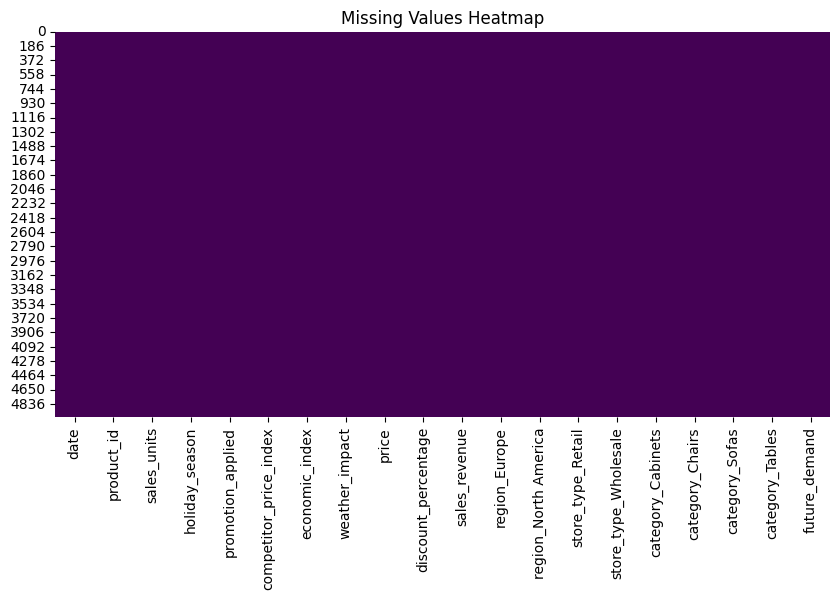

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
df.drop_duplicates()

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,economic_index,weather_impact,price,discount_percentage,sales_revenue,region_Europe,region_North America,store_type_Retail,store_type_Wholesale,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand
0,01-01-2023,151,99,0,0,0.983893,1.314333,0,126.932923,0.000000,12566.359330,False,False,True,False,False,True,False,False,95
1,02-01-2023,192,95,1,0,0.977615,1.439582,0,151.355405,0.000000,14378.763510,False,True,False,False,True,False,False,False,101
2,03-01-2023,114,101,0,0,0.983913,1.094795,0,191.701693,0.000000,19361.870950,False,False,False,True,True,False,False,False,33
3,04-01-2023,171,33,0,0,1.191956,0.907672,0,173.106487,0.000000,5712.514059,False,False,False,True,False,True,False,False,82
4,05-01-2023,160,82,0,1,0.855711,1.479690,0,138.587491,10.995213,10114.659150,True,False,False,False,False,False,True,False,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,03-09-2036,135,145,0,0,1.056679,1.070775,0,71.619056,0.000000,10384.763050,False,True,False,True,False,False,True,False,30
4995,04-09-2036,148,30,1,0,0.943824,0.588744,0,156.059583,0.000000,4681.787499,False,True,False,False,False,True,False,False,65
4996,05-09-2036,157,65,0,0,1.126866,0.744654,1,122.872619,0.000000,7986.720266,False,True,False,True,True,False,False,False,55
4997,06-09-2036,138,55,0,0,0.835702,1.409860,0,59.899614,0.000000,3294.478765,False,True,False,True,False,False,True,False,52


In [ ]:
df = df.drop(columns="economic_index")
df = df.drop(columns="discount_percentage")

In [ ]:
df = df.drop(columns="region_Europe")
df = df.drop(columns="region_North America")

In [ ]:
df

,date,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,weather_impact,price,sales_revenue,store_type_Retail,store_type_Wholesale,category_Cabinets,category_Chairs,category_Sofas,category_Tables,future_demand
0,01-01-2023,151,99,0,0,0.983893,0,126.932923,12566.359330,True,False,False,True,False,False,95
1,02-01-2023,192,95,1,0,0.977615,0,151.355405,14378.763510,False,False,True,False,False,False,101
2,03-01-2023,114,101,0,0,0.983913,0,191.701693,19361.870950,False,True,True,False,False,False,33
3,04-01-2023,171,33,0,0,1.191956,0,173.106487,5712.514059,False,True,False,True,False,False,82
4,05-01-2023,160,82,0,1,0.855711,0,138.587491,10114.659150,False,False,False,False,True,False,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,03-09-2036,135,145,0,0,1.056679,0,71.619056,10384.763050,False,True,False,False,True,False,30
4995,04-09-2036,148,30,1,0,0.943824,0,156.059583,4681.787499,False,False,False,True,False,False,65
4996,05-09-2036,157,65,0,0,1.126866,1,122.872619,7986.720266,False,True,True,False,False,False,55
4997,06-09-2036,138,55,0,0,0.835702,0,59.899614,3294.478765,False,True,False,False,True,False,52


In [ ]:
df.shape

(4999, 16)

In [ ]:
df.describe()

,product_id,sales_units,holiday_season,promotion_applied,competitor_price_index,weather_impact,price,sales_revenue,future_demand
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
mean,148.897780,103.287057,0.201240,0.291458,1.000817,0.143429,110.942274,10868.506475,103.293059
std,28.966902,54.805135,0.400967,0.454480,0.116095,0.350545,51.947268,8261.926164,54.806308
min,100.000000,10.000000,0.000000,0.000000,0.800081,0.000000,20.016788,205.710553,10.000000
25%,124.000000,56.000000,0.000000,0.000000,0.900912,0.000000,66.092894,4246.400672,56.000000
50%,148.000000,101.000000,0.000000,0.000000,0.999048,0.000000,111.391956,8746.124067,101.000000
75%,174.000000,151.000000,0.000000,1.000000,1.102838,0.000000,156.397044,15700.271470,151.000000
max,199.000000,199.000000,1.000000,1.000000,1.199929,1.000000,199.963480,39200.191690,199.000000


# **Importing Libraries**

In [ ]:
!pip install pytorch-lightning
!pip install pytorch-forecasting
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 55.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 728.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.4/848.4 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 15.3 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import shap

In [ ]:
df.dtypes

,0
date,object
product_id,int64
sales_units,int64
holiday_season,int64
promotion_applied,int64
competitor_price_index,float64
weather_impact,int64
price,float64
sales_revenue,float64
store_type_Retail,bool


In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# **Step 6 - Data Visualization**

Demand Distribution

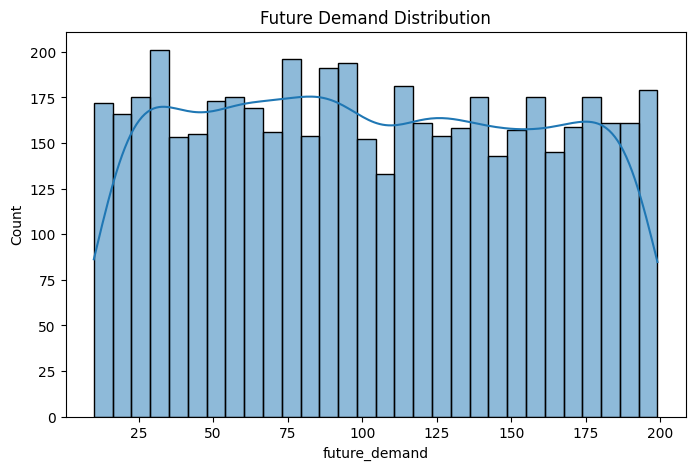

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['future_demand'], bins=30, kde=True)

plt.title("Future Demand Distribution")
plt.show()

Sales Trend

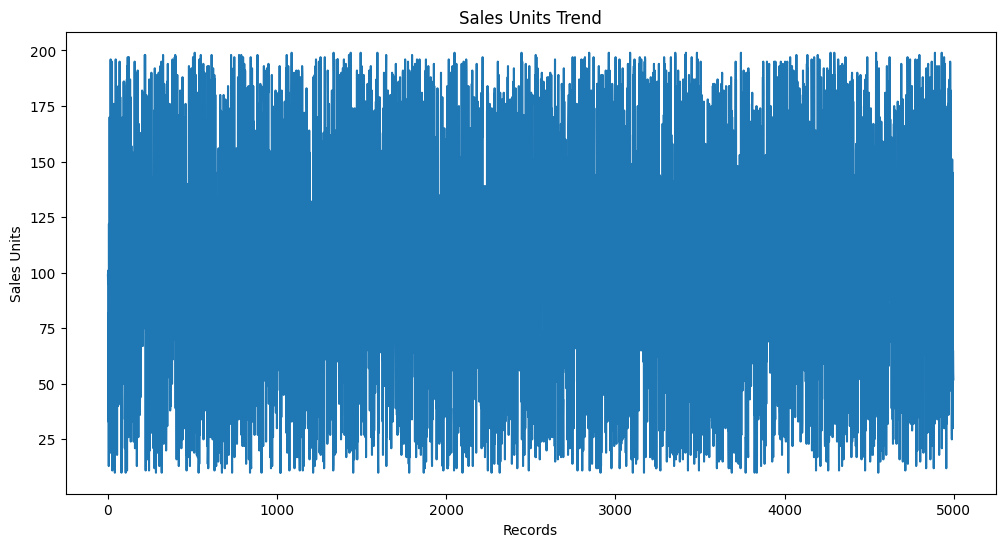

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['sales_units'])
plt.title("Sales Units Trend")
plt.xlabel("Records")
plt.ylabel("Sales Units")

plt.show()

Correlation Heatmap

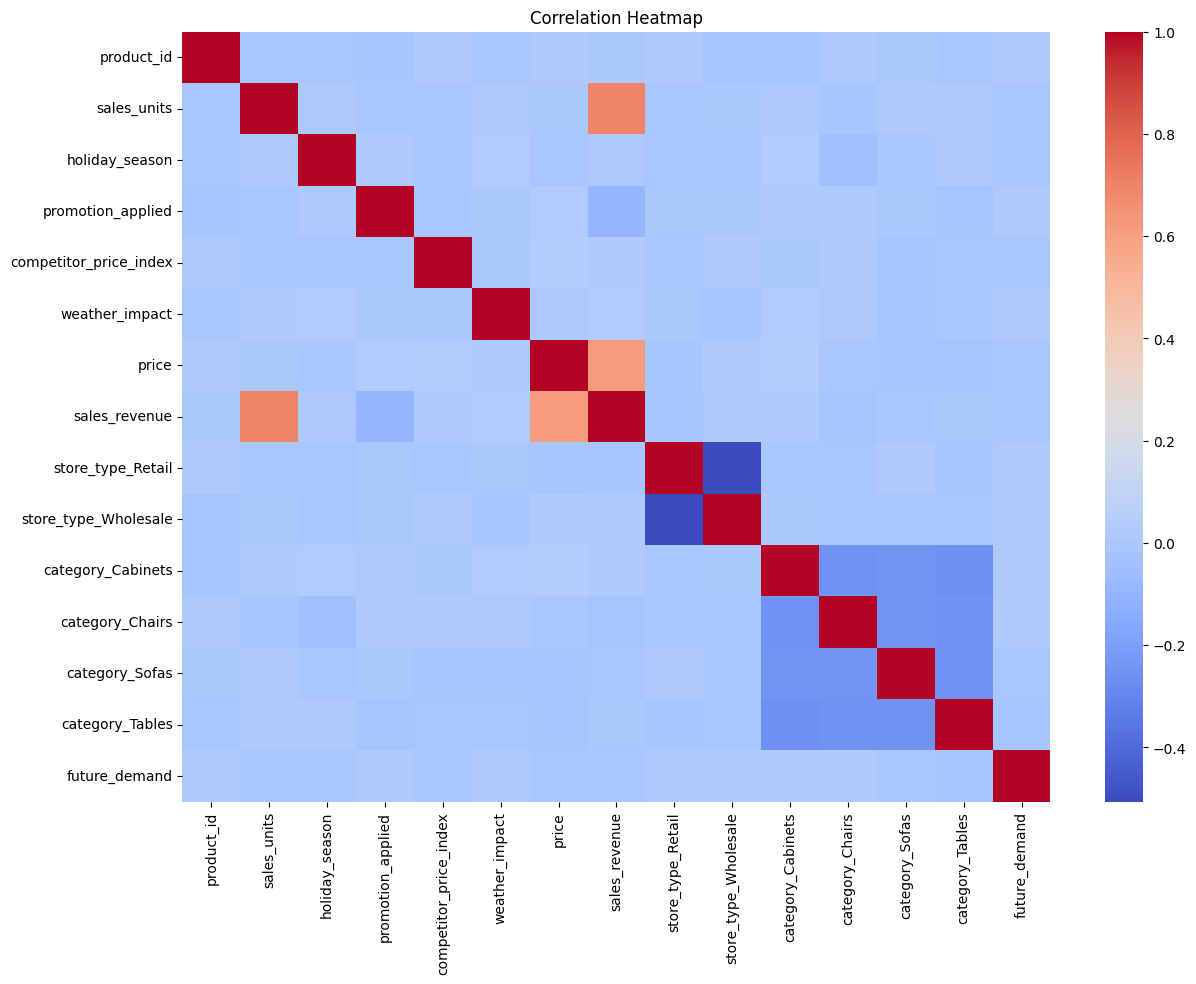

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm',
            annot=False)

plt.title("Correlation Heatmap")
plt.show()

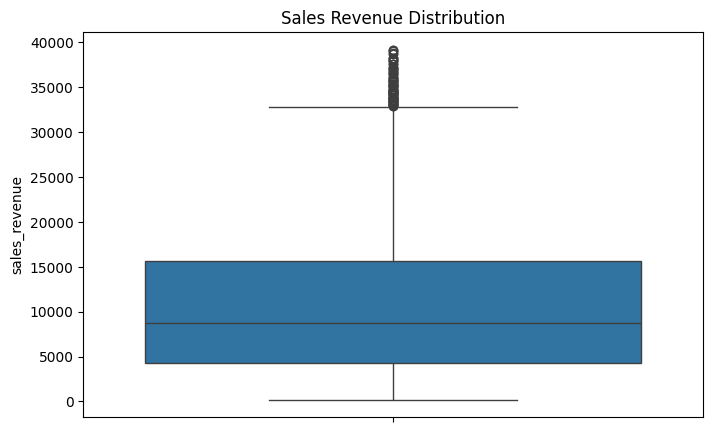

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['sales_revenue'])
plt.title("Sales Revenue Distribution")
plt.show()

# **Step 6 - Model Training and Evaluation**

In [ ]:
X = df.drop(['future_demand','date'], axis=1)
y = df['future_demand']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# **Step 7 -LSTM Model**

Reshaping Data for LSTM

Training the model

In [ ]:
X_train_lstm = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_lstm = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [ ]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_lstm.shape[1],1)
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_lstm,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 12368.2764 - mae: 96.7214 - val_loss: 11435.2461 - val_mae: 92.1091
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 11242.4512 - mae: 90.8418 - val_loss: 10790.8262 - val_mae: 88.6376
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 10648.7744 - mae: 87.6668 - val_loss: 10225.9775 - val_mae: 85.5812
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 10094.6973 - mae: 84.7107 - val_loss: 9699.7695 - val_mae: 82.7121
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 9586.9727 - mae: 82.0082 - val_loss: 9207.4561 - val_mae: 80.0180
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 9109.4209 - mae: 79.4685 - val_loss: 8747.4346 - val_mae: 77.4976
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8673.7285 - mae: 77.0997 - val_loss: 8314.2588 - val_mae: 75.1313
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8251.5664 - mae: 74.8547 - val_loss: 7909.1

Prediction

In [ ]:
predictions = model.predict(X_test_lstm)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


Evaluation

In [ ]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 71.51177978515625
MSE : 7642.5126953125
RMSE : 87.42146587259047
R2 Score : -1.4984431266784668


Graph for Actual vs Predicted

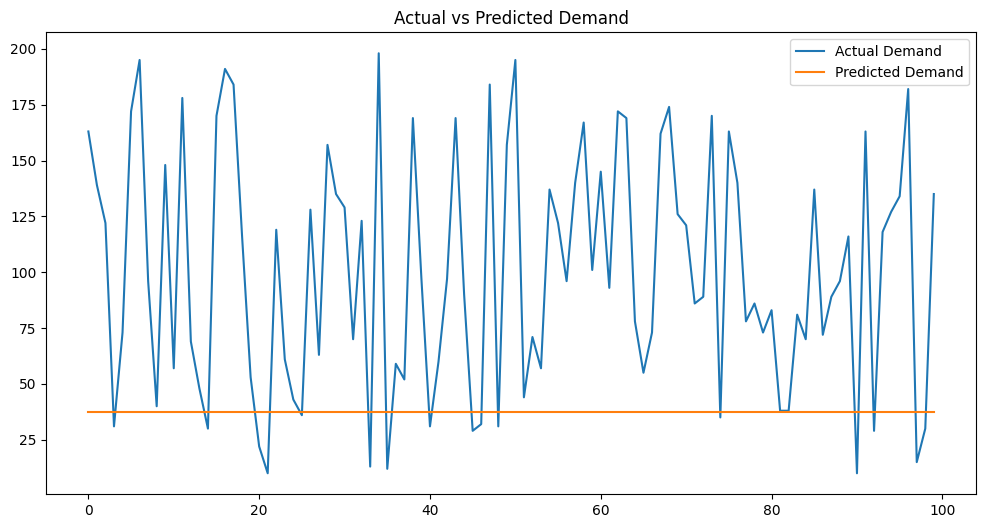

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:100],
         label='Actual Demand')
plt.plot(predictions[:100],
         label='Predicted Demand')

plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()

# **Step 8 - Transformer Model**

Importing Necessary Libraries

In [ ]:
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Model

In [ ]:
inputs = Input(
    shape=(X_train_lstm.shape[1],1)
)

attention = MultiHeadAttention(
    num_heads=2,
    key_dim=2
)(inputs, inputs)

x = LayerNormalization()(attention)

x = Dense(64, activation='relu')(x)

x = Flatten()(x)

outputs = Dense(1)(x)

transformer_model = Model(inputs, outputs)

transformer_model.compile(
    optimizer='adam',
    loss='mse'
)

transformer_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 14, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 14, 1)     │         29 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 14, 1)     │          2 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 14, 64)    │        128 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 896)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        897 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,056 (4.12 KB)

 Trainable params: 1,056 (4.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
transformer_model.fit(
    X_train_lstm,
    y_train,
    epochs=5,
    batch_size=32
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 13547.3730
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 13521.8027
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 13496.3271
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 13470.8848
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 13445.4971


# **Step 9 - SHAP**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
649/649 ━━━━━━

/tmp/ipykernel_2158/1002767511.py:41: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


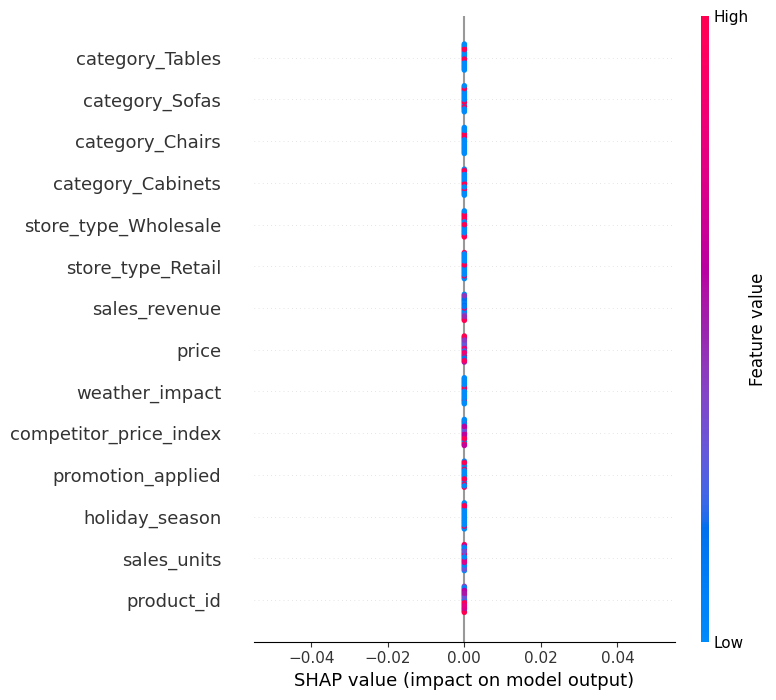

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Small sample for faster execution
sample_data = X_test_lstm[:20]

# Prediction function
def predict_fn(data):

    data = data.reshape(
        data.shape[0],
        X_test_lstm.shape[1],
        1
    )

    return model.predict(data).flatten()

# Flatten input for SHAP
sample_flat = sample_data.reshape(sample_data.shape[0], -1)

background = sample_flat[:10]

# Kernel Explainer
explainer = shap.KernelExplainer(
    predict_fn,
    background
)

# Generate SHAP values
shap_values = explainer.shap_values(
    sample_flat[:20]
)

# Convert properly
shap_values = np.array(shap_values)

# Plot
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    sample_flat[:20],
    feature_names=list(X.columns)
)

plt.show()

# **Step 10 - Temporal Fusion Transformer (TFT)**

In [ ]:
from pytorch_forecasting import TemporalFusionTransformer

print("Temporal Fusion Transformer Imported")

Temporal Fusion Transformer Imported


Forecasting Visualization

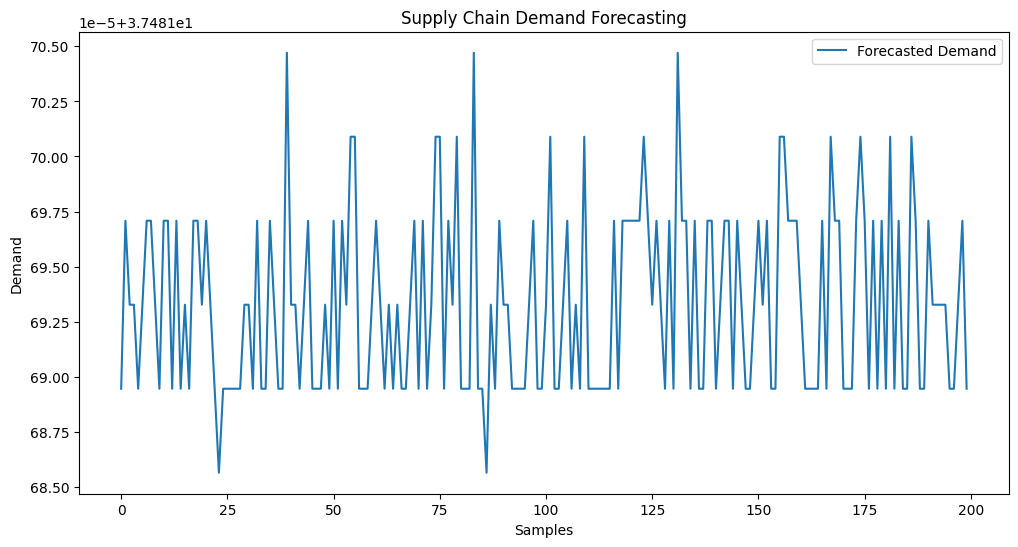

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(predictions[:200],
         label='Forecasted Demand')

plt.title("Supply Chain Demand Forecasting")

plt.xlabel("Samples")

plt.ylabel("Demand")

plt.legend()

plt.show()


In [1]:
!pip install nbstripout

In [2]:
!jupyter nbconvert \
--ClearOutputPreprocessor.enabled=True \
--inplace \
/content/*.ipynb

[NbConvertApp] WARNING | pattern '/content/*.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    